In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [65]:
filename_caII = '/Volumes/ViSP_External/CaII_11Aug2024_Cclass_newcalib.npz'
filename_hbeta = '/Volumes/ViSP_External/Hbeta_11Aug2024_Cclass_newcalib.npz'

line = 2

In [67]:
if line == 0 or line == 1:
    ViSPspec = np.load(filename_caII)
elif line == 2:
    ViSPspec = np.load(filename_hbeta)

    

In [68]:
flare = ViSPspec['flare']

In [69]:
times = ViSPspec['time']

In [70]:
np.shape(flare)

(999, 902, 2548)

In [71]:
if line == 0:
    line_low = 480 
    line_high = 690
elif line == 1:
    line_low = 685
    line_high = 810
elif line == 2:
    line_low =353
    line_high = 640

In [72]:
framesel = flare[57:-31,:,:]

In [73]:
linesum = np.nansum(framesel[:,line_low:line_high,:],1)

In [74]:
linemean = []
for i in range(10):
    linemean.append(np.nansum(linesum[(91*i)+1:(91*(i+1))+1,:]))

In [75]:
np.shape(linemean)

(10,)

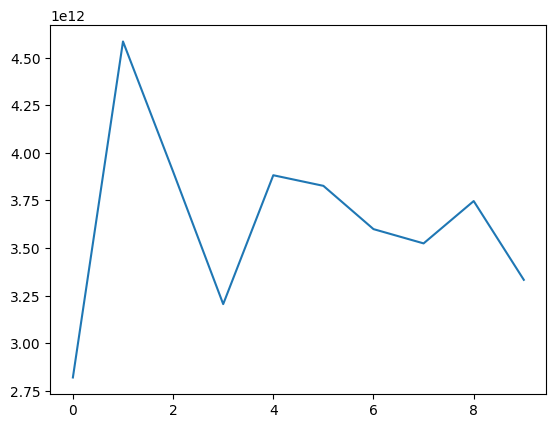

In [76]:
plt.plot(linemean)

In [77]:
times0 = times[57:-32]

In [78]:
timessave = times0[0:-1:91]

In [79]:
timessave

array(['2024-08-11T22:32:58.533532', '2024-08-11T22:33:19.500789',
       '2024-08-11T22:33:40.518206', '2024-08-11T22:34:01.535624',
       '2024-08-11T22:34:22.502881', '2024-08-11T22:34:43.520299',
       '2024-08-11T22:35:04.537716', '2024-08-11T22:35:25.504973',
       '2024-08-11T22:35:46.522391', '2024-08-11T22:36:07.539808'],
      dtype='<U26')

In [80]:
if line == 0:
    np.savez('/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/caiih_lc.npz',lc=linemean,times=timessave)
elif line == 1:
    np.savez('/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/hep_lc.npz',lc=linemean,times=timessave)
elif line == 2:
    np.savez('/Users/coletamburri/Desktop/DKIST_Flares/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/hbeta_lc.npz',lc=linemean,times=timessave)

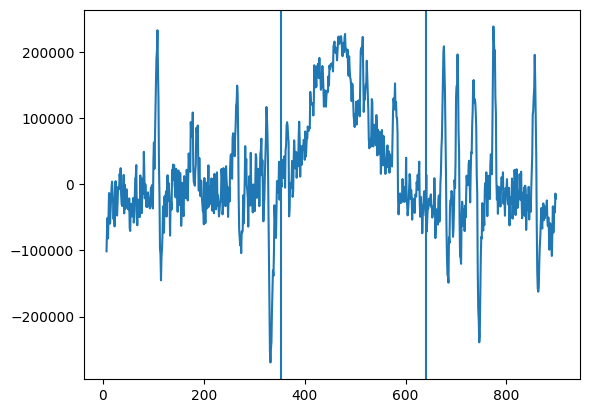

In [81]:
plt.plot(framesel[130,:,1200])
plt.axvline(line_low)
plt.axvline(line_high)